# Airbnb Price Analysis & Prediction (NYC Dataset)

## Objective
The objective of this project is to analyze Airbnb listings data to understand pricing patterns and identify key factors affecting listing prices. Additionally, a machine learning model is built to predict prices based on available features.

## Data Loading

The dataset contains information about Airbnb listings in New York City, including details such as location, room type, price, availability, and reviews. The data is loaded into a pandas DataFrame for analysis.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/AB_NYC_2019.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Data Understanding

We explore the dataset to understand its structure, data types, and overall distribution of values.

In [30]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


### Insight:
- Dataset contains multiple numerical and categorical features
- Price is the target variable
- Some columns contain missing values

## Data Cleaning

The dataset contains missing values and unnecessary columns. The following steps are performed:

- Removed irrelevant columns such as id, name, and host_name
- Handled missing values in reviews_per_month
- Converted categorical variables using one-hot encoding
- Removed non-numeric columns for modeling

In [6]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [7]:
df['reviews_per_month'].fillna(0, inplace=True)
df.drop(['name', 'host_name'], axis=1, inplace=True)

/tmp/ipykernel_6590/54454151.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews_per_month'].fillna(0, inplace=True)


### Insight:
- Missing values handled in reviews_per_month
- Unnecessary columns removed for better analysis

## Basic Exploration

Understanding distribution of categorical features.

In [31]:
df['room_type'].value_counts()
df['neighbourhood_group'].value_counts()

,count
neighbourhood_group,
Manhattan,21661
Brooklyn,20104
Queens,5666
Bronx,1091
Staten Island,373


## Price Distribution

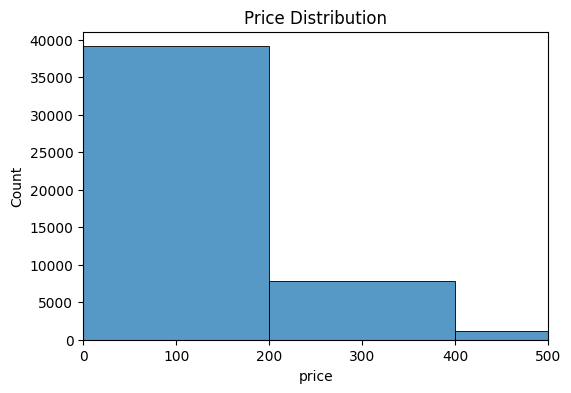

In [32]:
plt.figure(figsize=(6,4))
sns.histplot(df['price'], bins=50)
plt.xlim(0,500)
plt.title("Price Distribution")
plt.show()

### Insight:
- Most listings are priced under $200
- Few extreme values indicate presence of outliers
- Distribution is right-skewed

## Price by Room Type

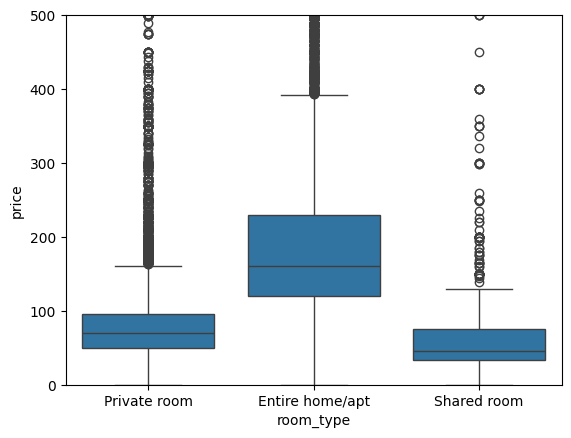

In [33]:
sns.boxplot(x='room_type', y='price', data=df)
plt.ylim(0,500)
plt.show()

### Insight:
- Entire homes are most expensive
- Private rooms are moderately priced
- Shared rooms are cheapest

## Location Analysis

In [34]:
df.groupby('neighbourhood_group')['price'].mean().sort_values()

,price
neighbourhood_group,
Bronx,87.496792
Queens,99.517649
Staten Island,114.812332
Brooklyn,124.383207
Manhattan,196.875814


### Insight:
- Manhattan has highest average prices
- Brooklyn follows
- Other areas are more affordable

## Correlation Analysis

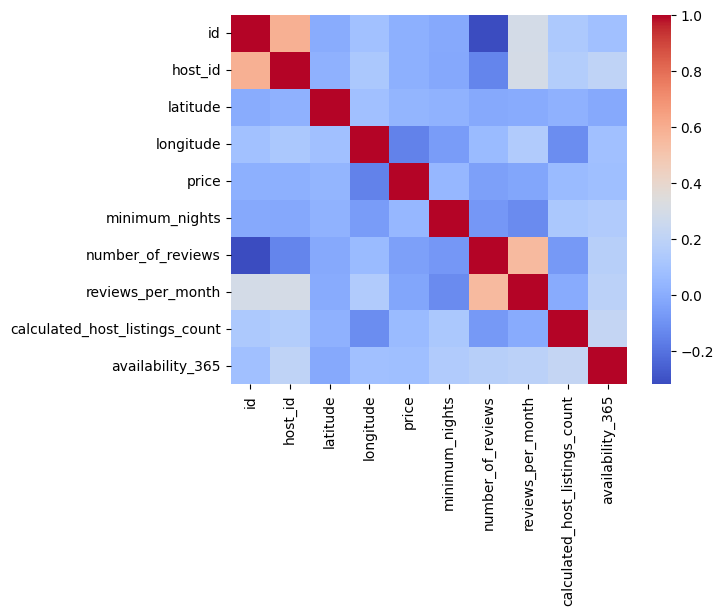

In [35]:
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

### Insight:
- Weak linear relationships with price
- Price influenced more by categorical factors

## Data Preparation for Modeling

In [24]:
df = pd.read_csv('/content/AB_NYC_2019.csv')

# Drop useless columns
df.drop(['id','name','host_name','last_review'], axis=1, inplace=True)

# Handle missing
df['reviews_per_month'].fillna(0, inplace=True)

# Convert categorical
df = pd.get_dummies(df, columns=['neighbourhood_group','room_type'], drop_first=True)

# Drop remaining text
df.drop(['neighbourhood'], axis=1, inplace=True)

# Split
X = df.drop(['price'], axis=1)
y = df['price']

/tmp/ipykernel_6590/2203108447.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews_per_month'].fillna(0, inplace=True)


## Model Building

A Linear Regression model is used for price prediction.

In [25]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

LinearRegression()

## Model Evaluation

In [27]:
from sklearn.metrics import mean_absolute_error, r2_score

pred = model.predict(X)

print("MAE:", mean_absolute_error(y, pred))
print("R2 Score:", r2_score(y, pred))

MAE: 73.9432326603168
R2 Score: 0.09902982479099764


The model captures general pricing trends but struggles with extreme values due to the presence of outliers and real-world data complexity.

### Insight:
- MAE shows average prediction error
- R² indicates how well model explains price
- Model captures general trends but not all variations

## Actual vs Predicted Prices

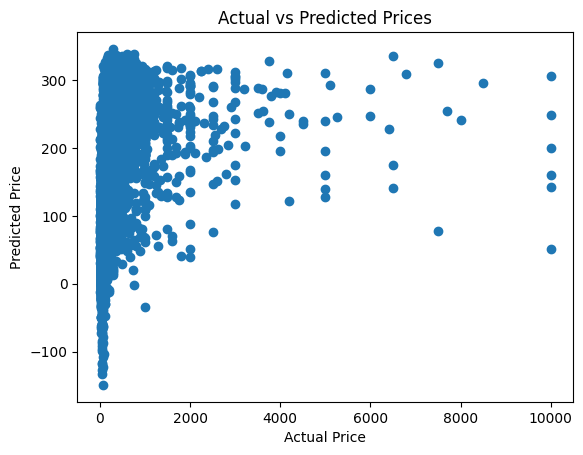

In [36]:
import matplotlib.pyplot as plt

plt.scatter(y, pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

### Insight:
- Predictions follow general trend
- Some deviations due to real-world complexity

## Key Insights

- Manhattan listings are the most expensive
- Entire homes generate higher revenue
- Price distribution is highly skewed
- Location and room type are strongest factors
- Reviews do not strongly influence price

## Conclusion

This project analyzed Airbnb data to understand pricing patterns and build a predictive model.

- Data cleaning and EDA revealed key trends
- Location and room type significantly impact price
- Linear Regression provided baseline predictions
- Real-world complexity limits model accuracy

This project demonstrates practical data analysis and machine learning skills.
This project demonstrates how data analysis can support pricing strategies and decision-making in the hospitality industry.